# 2. From MATPOWER to QUBO

**Reading time: about 30 minutes. Prerequisite: notebook 1.**

Notebook 1 called `qg.problems.Islanding(net)` and treated the resulting QUBO as
a black box. This notebook opens it. You will:

1. Load your own MATPOWER `.m` file into a `Network` and read its arrays by
   column name.
2. Build an economic dispatch QUBO by hand, term by term, and verify it against
   the library formulation.
3. Measure what happens when a penalty weight is too small and when it is too
   large. Both failures are shown with numbers from this notebook, not claims.
4. Read the default penalty weights and state exactly what they optimize.

This is the layer where research decisions are made. A quantum computer receives
only the matrix `Q`; everything an operator cares about has to survive the trip
into that matrix.

In [1]:
import tempfile
from importlib import resources
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import qugrid as qg
from qugrid import idx
from qugrid.classical.dispatch import GenParams, economic_dispatch
from qugrid.network import Network
from qugrid.problems import EconomicDispatchQUBO, QUBOBuilder

qg.viz.use_style()
np.set_printoptions(precision=3, suppress=True)

## 2.1 Getting a case in

QuGrid reads MATPOWER case files directly. The parser handles the standard data
files: assignments of scalars, strings, and numeric matrices to fields of a
struct named `mpc`. It does not evaluate MATLAB code, and it reports that
clearly when it meets some.

The bundled cases are ordinary `.m` files inside the package, so the same call
works on them as on a file of your own.

In [2]:
bundled = resources.files("qugrid.cases").joinpath("data/case9.m")
with resources.as_file(bundled) as path:
    print("bundled case file:", Path(path).name)
    net = Network.from_matpower(str(path))
print(net)

bundled case file: case9.m
Network('case9': 9 buses, 9 branches, 3 generators, load 315.0 MW)


Now the same call on a case you write yourself. The three-bus system below is a
complete MATPOWER data file: a slack bus with a cheap generator, a PV bus with
an expensive generator, and one load bus.

In [3]:
MY_CASE = """
function mpc = mycase
mpc.version = '2';
mpc.baseMVA = 100;
% bus_i type  Pd   Qd  Gs Bs area Vm Va baseKV zone Vmax Vmin
mpc.bus = [
    1     3    0    0   0  0   1   1  0   230    1   1.1  0.9;
    2     2    0    0   0  0   1   1  0   230    1   1.1  0.9;
    3     1  120   40   0  0   1   1  0   230    1   1.1  0.9;
];
% bus  Pg  Qg Qmax Qmin Vg mBase status Pmax Pmin
mpc.gen = [
    1    80   0  100 -100  1   100     1  150    0;
    2    45   0  100 -100  1   100     1  100    0;
];
% fbus tbus   r     x    b  rateA rateB rateC ratio angle status angmin angmax
mpc.branch = [
    1    2   0.01  0.06  0    200   200   200     0     0      1   -360    360;
    1    3   0.01  0.08  0    200   200   200     0     0      1   -360    360;
    2    3   0.01  0.07  0    200   200   200     0     0      1   -360    360;
];
"""

with tempfile.TemporaryDirectory() as folder:
    case_path = Path(folder) / "mycase.m"
    case_path.write_text(MY_CASE)
    mine = Network.from_matpower(str(case_path))
print(mine)
print("load per bus [MW]      ", mine.load_p)
print("generation per bus [MW]", mine.gen_p_per_bus())

Network('mycase': 3 buses, 3 branches, 2 generators, load 120.0 MW)
load per bus [MW]       [  0.   0. 120.]
generation per bus [MW] [80. 45.  0.]


Two more routes exist and need no explanation beyond the call itself:

* `Network.from_pandapower(pp_net)` converts a pandapower network. It requires
  `pip install "qugrid[pandapower] @ git+https://github.com/TravisCao/qugrid"`,
  so it is not executed here. After the planned PyPI release, the command
  shortens to `pip install qugrid[pandapower]`.
* `net.to_ppc()` exports a PYPOWER-compatible dict, and `Network.from_ppc(ppc)`
  reads one back. The round trip is lossless, which is the check below.

In [4]:
ppc = net.to_ppc()
print("ppc keys:", sorted(ppc.keys()))
back = Network.from_ppc(ppc, name="round-trip")
print("bus arrays identical:   ", np.array_equal(net.bus, back.bus))
print("branch arrays identical:", np.array_equal(net.branch, back.branch))

ppc keys: ['baseMVA', 'branch', 'bus', 'gen', 'gencost', 'version']
bus arrays identical:    True
branch arrays identical: True


## 2.2 Reading the case arrays by column name

`qugrid.idx` gives every MATPOWER column its standard name, so no code in QuGrid
ever contains a bare column number. The names follow the MATPOWER manual,
appendix B.

In [5]:
print("bus columns   PD =", idx.PD, " QD =", idx.QD, " BUS_TYPE =", idx.BUS_TYPE, " VM =", idx.VM)
print("gen columns   PG =", idx.PG, " PMAX =", idx.PMAX, " PMIN =", idx.PMIN)
print("branch cols   BR_X =", idx.BR_X, " RATE_A =", idx.RATE_A, " BR_STATUS =", idx.BR_STATUS)
print("bus types     PQ =", idx.PQ, " PV =", idx.PV, " REF =", idx.REF)

bus columns   PD = 2  QD = 3  BUS_TYPE = 1  VM = 7
gen columns   PG = 1  PMAX = 8  PMIN = 9
branch cols   BR_X = 3  RATE_A = 5  BR_STATUS = 10
bus types     PQ = 1  PV = 2  REF = 3


In [6]:
print("branch reactance x [pu] :", net.branch[:, idx.BR_X])
print("branch rating A [MVA]   :", net.branch[:, idx.RATE_A])
print("generator limits [MW]   :")
for g in range(net.n_gen):
    at_bus = int(net.bus[net.gen_bus[g], idx.BUS_I])
    print(
        f"   unit {g} at bus {at_bus}: "
        f"Pmin {net.gen[g, idx.PMIN]:6.1f}  Pmax {net.gen[g, idx.PMAX]:6.1f}  "
        f"Pg {net.gen[g, idx.PG]:6.1f}"
    )

branch reactance x [pu] : [0.058 0.092 0.17  0.059 0.101 0.072 0.062 0.161 0.085]
branch rating A [MVA]   : [250. 250. 150. 300. 150. 250. 250. 250. 250.]
generator limits [MW]   :
   unit 0 at bus 1: Pmin   10.0  Pmax  250.0  Pg   72.3
   unit 1 at bus 2: Pmin   10.0  Pmax  300.0  Pg  163.0
   unit 2 at bus 3: Pmin   10.0  Pmax  270.0  Pg   85.0


`Network` computes the standard derived quantities from these arrays: `ybus()`
for the complex bus admittance matrix, `bdc()` for the DC power flow matrices,
`sbus()` for complex bus injections, `edges()` for the graph. Notebook 4 uses
`bdc()`. Two transformations return a modified copy and leave the original
untouched: `scale_loads(factor)` and `drop_branch(k)`, the N-1 outage.

In [7]:
stressed = net.scale_loads(1.3)
outage = net.drop_branch(6)
print("original total load [MW]:", net.load_p.sum())
print("scaled   total load [MW]:", stressed.load_p.sum())
print("branches in service, original:", int(net.branch_on.sum()))
print("branches in service, N-1     :", int(outage.branch_on.sum()))

original total load [MW]: 315.0
scaled   total load [MW]: 409.5
branches in service, original: 9
branches in service, N-1     : 8


## 2.3 Economic dispatch by hand

Single-period economic dispatch of committed units. Each unit `g` has a
quadratic cost `c2 P^2 + c1 P + c0` in dollars per hour and limits
`pmin <= P <= pmax`. The units must together meet a demand `D`.

### The obstacle: `P` is continuous, a QUBO takes bits

The standard answer is **binary expansion**. Choose `K` bits per unit and write

```
P_g = pmin_g + delta_g * (b_0 * 2^0 + b_1 * 2^1 + ... + b_{K-1} * 2^{K-1})
delta_g = (pmax_g - pmin_g) / (2^K - 1)
```

The bits count from 0 to `2^K - 1`, so the expression reaches `2^K` equally
spaced outputs from `pmin` to `pmax`, adjacent ones `delta_g` apart. `delta_g`
is the **discretization step**: the finest output change the encoding can
represent. It is the first quantity to report in any QUBO dispatch study,
because the answer can never be more precise than one step.

In [8]:
gens = [
    GenParams("G1", pmin=20, pmax=80, c2=0.02, c1=15, c0=100),
    GenParams("G2", pmin=20, pmax=60, c2=0.05, c1=30, c0=200),
]
DEMAND = 100.0
POWER_BITS = 2

for g in gens:
    delta = (g.pmax - g.pmin) / (2**POWER_BITS - 1)
    levels = [g.pmin + delta * level for level in range(2**POWER_BITS)]
    print(f"{g.name}: delta = {delta:6.2f} MW, reachable outputs = {np.round(levels, 2)}")

G1: delta =  20.00 MW, reachable outputs = [20. 40. 60. 80.]
G2: delta =  13.33 MW, reachable outputs = [20.   33.33 46.67 60.  ]


### The builder

`QUBOBuilder` assembles a QUBO from named variables. Four methods do everything:

* `var(name)` registers a binary variable and returns its index. Calling it twice
  with the same name returns the same index.
* `add_linear(i, c)` adds `c * x_i`.
* `add_quadratic(i, j, c)` adds `c * x_i * x_j`. Because `x*x = x` for a binary
  variable, passing `i == j` is redirected to `add_linear`.
* `add_squared_penalty(terms, constant, weight)` adds
  `weight * (sum_i coef_i * x_i + constant)^2`, expanded exactly. `terms` is a
  list of `(index, coefficient)` pairs.

`add_squared_penalty` is the workhorse. Every equality constraint
`sum_i a_i x_i = b` becomes the penalty `weight * (sum_i a_i x_i - b)^2`, which
is zero when the constraint holds and positive when it does not.

The same method also expands the quadratic cost term, because
`c2 * P^2 = c2 * (pmin + sum_k delta 2^k b_k)^2` has exactly that shape.

In [9]:
builder = QUBOBuilder()
balance_terms: list[tuple[int, float]] = []

for g, gen in enumerate(gens):
    delta = (gen.pmax - gen.pmin) / (2**POWER_BITS - 1)
    bits = [builder.var(f"b[{g},{k}]") for k in range(POWER_BITS)]
    # P_g - pmin_g, written as a list of (variable index, coefficient) pairs
    p_terms = [(bits[k], delta * 2**k) for k in range(POWER_BITS)]

    builder.add_squared_penalty(p_terms, gen.pmin, weight=gen.c2)  # c2 * P^2
    for index, coefficient in p_terms:  # c1 * (P - pmin)
        builder.add_linear(index, gen.c1 * coefficient)
    builder.add_constant(gen.c1 * gen.pmin + gen.c0)  # the rest of c1 * P, plus c0

    balance_terms.extend(p_terms)

One penalty remains: the power balance. Total generation is
`sum_g pmin_g + sum over all bits`, so the constraint
`total generation = D` becomes a squared penalty with constant
`sum_g pmin_g - D`.

The weight is taken from the library formulation so the two constructions can be
compared coefficient by coefficient. Section 2.4 derives where such a number
comes from.

In [10]:
library = EconomicDispatchQUBO(gens, demand=DEMAND, power_bits=POWER_BITS)
total_pmin = sum(g.pmin for g in gens)
builder.add_squared_penalty(balance_terms, total_pmin - DEMAND, weight=library.weight_balance)
by_hand = builder.build()

print("variables         ", by_hand.names)
print("Q identical to the library formulation:", np.allclose(by_hand.q, library.qubo.q))
print("offset by hand    ", round(by_hand.offset, 3))
print("offset in library ", round(library.qubo.offset, 3))
print("offsets identical :", np.isclose(by_hand.offset, library.qubo.offset))

variables          ['b[0,0]', 'b[0,1]', 'b[1,0]', 'b[1,1]']
Q identical to the library formulation: True
offset by hand     147352.0
offset in library  147352.0
offsets identical : True


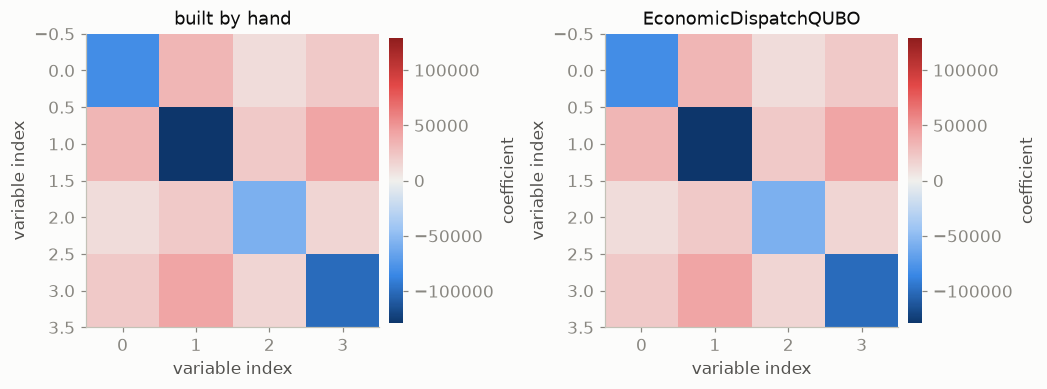

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0))
qg.viz.plot_qubo(by_hand, ax=axes[0], title="built by hand")
qg.viz.plot_qubo(library.qubo, ax=axes[1], title="EconomicDispatchQUBO")
plt.tight_layout()
plt.show()

The two coefficient matrices are indistinguishable. The block structure comes
from the balance penalty: it couples every power bit to every other, including
bits belonging to different units, because all of them appear in the same
squared term. Cost terms only ever couple bits within one unit, so a QUBO with
no balance penalty would show two blocks along the diagonal and nothing else.

The `Q` matrices and the constants both match: the eleven-line loop above *is*
the library formulation. That is the property to demand from any encoding you
use — you can rebuild it by hand and check every coefficient.

One reading habit still matters. At the optimum of a balanced instance the
QUBO objective equals the generation cost, but away from balance it also
carries the penalty term `weight * (imbalance)^2`. **Read
`result.decoded["cost"]` for the dollars-per-hour number**; `result.objective`
is the quantity the solver minimizes, and the two agree only when the balance
constraint is met exactly.

The check below confirms both statements on this instance: same minimizer, and
the objective at the balanced optimum equals the decoded cost.

In [12]:
solution = qg.solve(library, solver="exact")
x_star = solution.x
print("optimal bits              ", x_star)
print("dispatch [MW]             ", library.power(x_star))
print("decoded cost [$/h]        ", library.decode(x_star)["cost"])
print("hand-built QUBO objective ", round(by_hand.energy(x_star), 3))
print("library QUBO objective    ", round(library.qubo.energy(x_star), 3))
print("continuous optimum        ", library.continuous_reference())

optimal bits               [1 1 0 0]
dispatch [MW]              [80. 20.]
decoded cost [$/h]         2248.0
hand-built QUBO objective  2248.0
library QUBO objective     2248.0
continuous optimum         {'power': array([80., 20.]), 'cost': 2248.0}


## 2.4 Penalty weights, measured

The penalty weight is the only free number in the formulation, and getting it
wrong is the most common way a QUBO study produces a wrong answer. Both failure
directions are measurable, so measure them.

The test instance is three units with fixed output, and a demand that two
different combinations can meet exactly:

| Unit | Output if on | Cost if on |
| --- | --- | --- |
| A | 60 MW | \$2400/h |
| B | 40 MW | \$2000/h |
| C | 40 MW | \$2200/h |

Demand is 100 MW. Turning on A and B costs \$4400/h; A and C costs \$4600/h. The
correct answer is A and B. Anything that fails to serve exactly 100 MW is
infeasible.

In [13]:
CAPS = np.array([60.0, 40.0, 40.0])
COSTS = np.array([2400.0, 2000.0, 2200.0])
UNIT_DEMAND = 100.0


def three_unit_qubo(weight: float):
    """Cost plus a balance penalty of the given weight."""
    b = QUBOBuilder()
    u = [b.var(name) for name in ("A", "B", "C")]
    for i, cost in enumerate(COSTS):
        b.add_linear(u[i], float(cost))
    b.add_squared_penalty(
        [(u[i], float(CAPS[i])) for i in range(3)], -UNIT_DEMAND, weight=weight
    )
    return b.build()


def report(weight: float) -> dict:
    q = three_unit_qubo(weight)
    states = np.array([q.bits_from_index(k) for k in range(8)])
    energies = np.array([q.energy(x) for x in states])
    served = states @ CAPS
    feasible = np.flatnonzero(np.isclose(served, UNIT_DEMAND))
    ordered = np.sort(energies[feasible])
    return {
        "weight": weight,
        "argmin": "".join(map(str, states[int(energies.argmin())])),
        "served_mw": float(served[int(energies.argmin())]),
        "feasible_gap": float(ordered[1] - ordered[0]),
        "energy_spread": float(energies.max() - energies.min()),
    }


rows = [report(w) for w in (0.05, 0.5, 5.0, 50.0, 5000.0, 5e5)]
print(f"{'weight':>10} {'argmin':>7} {'served MW':>10} {'cost gap':>10} "
      f"{'spread':>12} {'gap/spread':>12}")
for r in rows:
    ratio = r["feasible_gap"] / r["energy_spread"]
    print(f"{r['weight']:>10g} {r['argmin']:>7} {r['served_mw']:>10.1f} "
          f"{r['feasible_gap']:>10.1f} {r['energy_spread']:>12.4g} {ratio:>12.2e}")

    weight  argmin  served MW   cost gap       spread   gap/spread
      0.05     000        0.0      200.0         6180     3.24e-02
       0.5     100       60.0      200.0         4200     4.76e-02
         5     110      100.0      200.0     4.56e+04     4.39e-03
        50     110      100.0      200.0    4.956e+05     4.04e-04
      5000     110      100.0      200.0        5e+07     4.00e-06
    500000     110      100.0      200.0        5e+09     4.00e-08


Read the table one column at a time.

**Weight too small (0.05 and 0.5).** The minimizer is `000` at weight 0.05 —
serve nothing, pay nothing — and `100` at weight 0.5, which serves 60 MW against
a 100 MW demand. The penalty is cheaper than the electricity, so the optimizer
buys the violation. This failure is silent: the solver reports a low objective
and a confident answer. The only defence is `result.feasible`, which checks the
original constraint rather than the penalized objective.

**Weight adequate (5 to 5000).** The minimizer is `110`, units A and B, serving
exactly 100 MW. This is the correct answer.

**Weight too large (500000).** The minimizer is still `110`, so the mathematics
is still right. What collapses is resolution. The cost difference between the
best and second-best feasible schedules stays at \$200/h, but the total energy
spread of the QUBO grows with the weight, so that \$200 shrinks to about 4 parts
in 100 million of the range. Any solver with finite precision stops being able to
see it: an annealer with limited coupler precision, a variational algorithm
reading a finite number of shots, or a heuristic with a fixed convergence
tolerance. The right answer becomes indistinguishable from the wrong one.

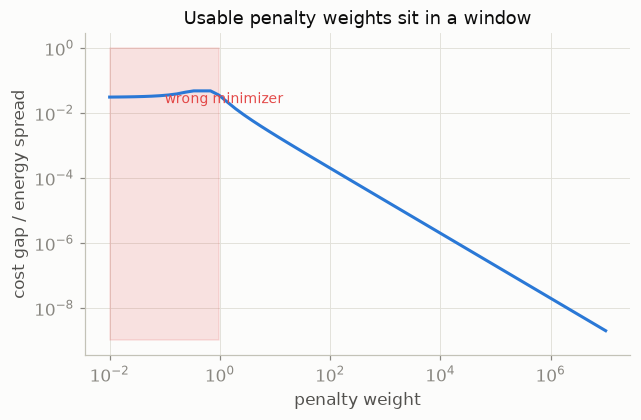

In [14]:
weights = np.logspace(-2, 7, 60)
ratios = [report(w)["feasible_gap"] / report(w)["energy_spread"] for w in weights]
correct = np.array([report(w)["argmin"] == "110" for w in weights])

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.loglog(weights, ratios, color=qg.viz.PALETTE[0])
ax.fill_between(weights, 1e-9, 1, where=~correct, color=qg.viz.PALETTE[7], alpha=0.15)
ax.annotate("wrong minimizer", (0.1, 2e-2), color=qg.viz.PALETTE[7], fontsize=9)
ax.set_xlabel("penalty weight")
ax.set_ylabel("cost gap / energy spread")
ax.set_title("Usable penalty weights sit in a window")
plt.show()

The shaded region on the left is where the minimizer is the wrong schedule. To
its right the answer is correct, and the curve falls as the weight grows: the
information a solver must resolve becomes a smaller and smaller fraction of the
energy range. A workable weight is the smallest one that makes every constraint
violation cost more than any feasible cost saving.

## 2.5 What the default weights optimize

`EconomicDispatchQUBO` sets the balance weight automatically:

```
weight_balance = 2 * (total cost at maximum output) / (smallest delta)^2
```

Read it as a statement about priorities. One discretization step of imbalance
costs `weight_balance * delta^2 = 2 * cost_ceiling`, which is more than the
entire range of dispatch costs. So the ground state of this QUBO minimizes the
**power imbalance first**, and uses cost only to break ties between dispatches
with equal imbalance. That ordering is deliberate — an operator does not accept
a cheaper schedule that fails to serve the load — but it must be stated, because
it is not what “minimize cost subject to a balance constraint” means when the
demand is not exactly reachable on the discretization grid.

Two instances make the difference visible. First, a demand that the grid can
reach exactly.

In [15]:
def dispatch_table(demand: float, top: int = 4) -> None:
    problem = EconomicDispatchQUBO(gens, demand=demand, power_bits=POWER_BITS)
    records = []
    for k in range(2**problem.qubo.n):
        x = problem.qubo.bits_from_index(k)
        decoded = problem.decode(x)
        records.append(
            (
                float(problem.qubo.energy(x)),
                decoded["power"][0],
                decoded["power"][1],
                decoded["balance_error_mw"],
                decoded["cost"],
            )
        )
    records.sort()
    print(f"demand {demand:.0f} MW   (balance weight {problem.weight_balance:.2f})")
    print(f"   {'QUBO energy':>12} {'P1':>7} {'P2':>7} {'|error|':>9} {'cost $/h':>10}")
    for energy, p1, p2, err, cost in records[:top]:
        print(f"   {energy:>12.1f} {p1:>7.2f} {p2:>7.2f} {err:>9.2f} {cost:>10.1f}")
    exact_p, exact_cost = economic_dispatch(gens, demand)
    print(f"   continuous optimum: P = {np.round(exact_p, 2)}, cost = {exact_cost:.1f}")


dispatch_table(100.0)

demand 100 MW   (balance weight 40.59)
    QUBO energy      P1      P2   |error|   cost $/h
         2248.0   80.00   20.00      0.00     2248.0
         2912.0   40.00   60.00      0.00     2912.0
         4131.6   60.00   33.33      6.67     2327.6
         4584.9   60.00   46.67      6.67     2780.9
   continuous optimum: P = [80. 20.], cost = 2248.0


Two dispatches serve 100 MW exactly, and the tie goes to the cheaper one:
80 + 20 MW at \$2248/h beats 40 + 60 MW at \$2912/h. Here the QUBO reproduces the
continuous optimum exactly, because the continuous optimum happens to sit on the
discretization grid.

Now a demand that the grid cannot reach.

In [16]:
dispatch_table(95.0)

demand 95 MW   (balance weight 40.59)
    QUBO energy      P1      P2   |error|   cost $/h
         2440.3   60.00   33.33      1.67     2327.6
         3262.8   80.00   20.00      5.00     2248.0
         3926.8   40.00   60.00      5.00     2912.0
         5259.6   40.00   46.67      8.33     2440.9
   continuous optimum: P = [75. 20.], cost = 2157.5


The ground state is 60 + 33.33 MW: it serves 93.33 MW, missing the target by
1.67 MW, and costs \$2327.6/h. The dispatch 80 + 20 MW is *cheaper* at
\$2248/h — but it misses the target by 5 MW, and under these weights that
5 MW of imbalance outweighs the \$79.6/h saving. The lexicographic ordering does
exactly what the weight says it should.

Two distinct errors follow, and conflating them is a standard mistake in the
literature:

* **Discretization gap** — QUBO optimum against the continuous optimum. Here
  \$2327.6 against \$2157.5, a gap of \$170.1/h, or 7.9 percent. It comes from
  the encoding alone and no solver can remove it. Add power bits to shrink it,
  at 1 more qubit per unit per bit.
* **Solver gap** — the answer a solver returns against the QUBO optimum. This is
  the only part a quantum algorithm can improve. `Result.gap()` reports it.

Report them separately, always.

In [17]:
for bits in (2, 3, 4, 5):
    problem = EconomicDispatchQUBO(gens, demand=95.0, power_bits=bits)
    best = qg.solve(problem, solver="exact")
    _, continuous_cost = economic_dispatch(gens, 95.0)
    decoded = best.decoded
    print(
        f"power_bits = {bits}: {problem.qubo.n:2d} variables, "
        f"step = {problem.delta.min():5.2f} MW, "
        f"served = {decoded['power'].sum():6.2f} MW, "
        f"|error| = {decoded['balance_error_mw']:4.2f} MW, "
        f"cost gap = {100 * (decoded['cost'] - continuous_cost) / continuous_cost:5.2f}%"
    )

power_bits = 2:  4 variables, step = 13.33 MW, served =  93.33 MW, |error| = 1.67 MW, cost gap =  7.88%
power_bits = 3:  6 variables, step =  5.71 MW, served =  94.29 MW, |error| = 0.71 MW, cost gap =  7.26%
power_bits = 4:  8 variables, step =  2.67 MW, served =  94.67 MW, |error| = 0.33 MW, cost gap =  1.48%
power_bits = 5: 10 variables, step =  1.29 MW, served =  94.84 MW, |error| = 0.16 MW, cost gap =  1.56%


Each added bit halves the step and costs one qubit per unit. The balance error
falls monotonically, from 1.67 MW at two bits to 0.16 MW at five. The cost gap
does not: it falls from 7.88 percent to 1.48 percent at four bits, then rises
slightly to 1.56 percent at five. That is section 2.5 again, visible in a
different place. The QUBO minimizes imbalance first, so a finer grid buys a more
balanced dispatch, and the cost of that dispatch is whatever it happens to be.
If cost is the quantity you report, refine the grid and check the cost, because
more qubits do not guarantee a cheaper answer under these weights.

## 2.6 Summary

* A MATPOWER `.m` file, a pandapower network, and a PYPOWER dict all enter
  through `Network`; `qugrid.idx` names every column.
* A continuous quantity becomes binary through binary expansion, at a cost fixed
  by the discretization step.
* An equality constraint becomes `weight * (violation)^2`. The weight has a
  usable window: too small and the minimizer is infeasible, too large and no
  finite-precision solver can resolve the objective inside the feasible set.
* The library defaults put balance ahead of cost by construction. Check
  `result.feasible` and `result.decoded`, not `result.objective` alone.

Notebook 3 takes a QUBO built this way and shows what a quantum optimizer does
with it.